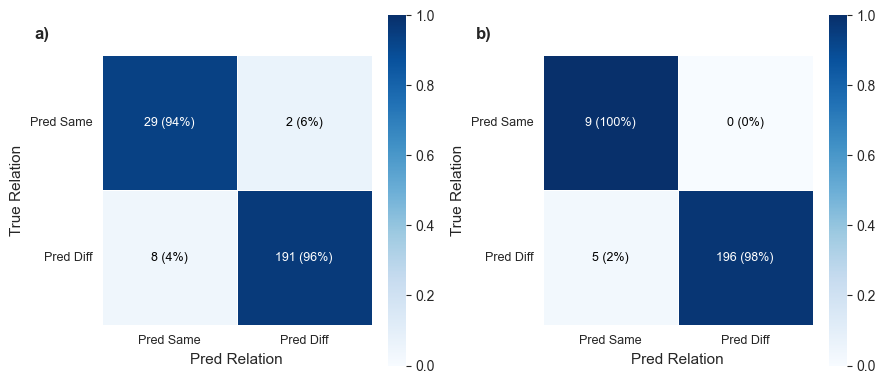

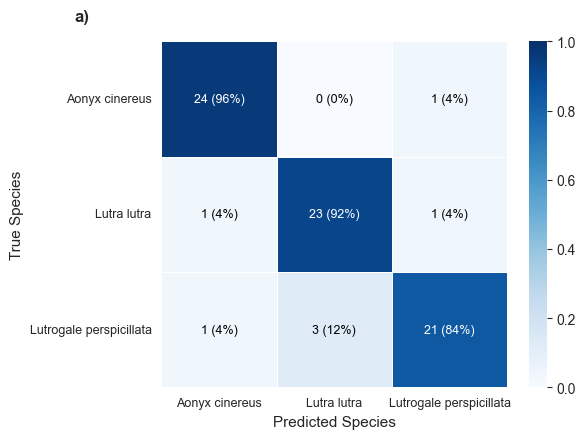

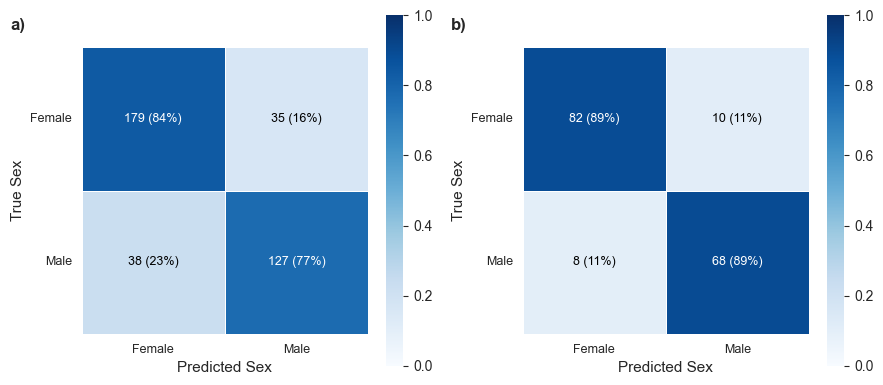

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --------------------------------------------------
# Einheitlicher Stil mit relativer Skala (0–1)
# --------------------------------------------------
def plot_confusion(ax, cm, labels, xlabel, ylabel, panel_label, cmap='Blues'):
    """Plot confusion matrix with relative scaling (0–1), bold panel label, and adaptive text colour."""
    cm = np.array(cm)
    row_sums = cm.sum(axis=1, keepdims=True)
    frac = cm / row_sums  # relative fractions 0–1

    sns.heatmap(
        frac,
        annot=False,
        fmt='',
        cmap=cmap,
        cbar=True,
        vmin=0, vmax=1,
        linewidths=0.5,
        linecolor='white',
        xticklabels=labels,
        yticklabels=labels,
        square=True,
        ax=ax
    )

    # Dynamische Textfarbe (weiß bei dunklen Feldern)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = 'white' if frac[i, j] > 0.5 else 'black'
            ax.text(j + 0.5, i + 0.5,
                    f"{cm[i,j]} ({frac[i,j]*100:.0f}%)",
                    ha='center', va='center',
                    color=color, fontsize=9)

    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.tick_params(axis='both', labelsize=9)
    plt.setp(ax.get_xticklabels(), rotation=0)
    plt.setp(ax.get_yticklabels(), rotation=0)

    # Panel label fett und linksbündig
    ax.text(-0.25, 1.05, panel_label, transform=ax.transAxes,
            fontsize=12, fontweight='bold', va='bottom', ha='left')

# --------------------------------------------------
# Daten
# --------------------------------------------------
# Pairwise
cm_pair_a = np.array([[29, 2],
                      [8, 191]])
cm_pair_b = np.array([[9, 0],
                      [5, 196]])
labels_pair = ['Pred Same', 'Pred Diff']

# Species (voll ausgeschrieben)
cm_species = np.array([[24, 0, 1],
                       [1, 23, 1],
                       [1, 3, 21]])
labels_species = [
    'Aonyx cinereus',
    'Lutra lutra',
    'Lutrogale perspicillata'
]

# Sex
cm_sex_a = np.array([[179, 35],
                     [38, 127]])
cm_sex_b = np.array([[82, 10],
                     [8, 68]])
labels_sex = ['Female', 'Male']

sns.set_style("white")

# --------------------------------------------------
# 1️⃣ Pairwise – a/b
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
plot_confusion(axes[0], cm_pair_a, labels_pair, 'Pred Relation', 'True Relation', 'a)')
plot_confusion(axes[1], cm_pair_b, labels_pair, 'Pred Relation', 'True Relation', 'b)')
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 2️⃣ Species – nur a)
# --------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(6, 4.5))
plot_confusion(ax, cm_species, labels_species, 'Predicted Species', 'True Species', 'a)')
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 3️⃣ Sex – a/b
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
plot_confusion(axes[0], cm_sex_a, labels_sex, 'Predicted Sex', 'True Sex', 'a)')
plot_confusion(axes[1], cm_sex_b, labels_sex, 'Predicted Sex', 'True Sex', 'b)')
plt.tight_layout()
plt.show()
